<a href="https://colab.research.google.com/github/FDC-PyArch8/z5688839-PHYS2116-Computational-Assignment/blob/main/z5688839_computational_assignment_stability_maps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rebound
!pip install multiprocess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 830.6/830.6 kB 17.2 MB/s eta 0:00:00


In [2]:
import rebound
import math
from multiprocess import Pool
import numpy as np
import matplotlib.pyplot as plt

In [3]:
"""
# test simulation of sun and Earth-mass planet

# initialising simulation
sim_sun = rebound.Simulation()

# formatting the value of G to fit the units below
sim_sun.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_sun.G))

# adding particles of mass m and semi-major axis a
sim_sun.add(m=1.0)
sim_sun.add(m=1.0e-3, a=1.0)

#integrating orbit
sim_sun.integrate(10000)
orbits = sim_sun.orbits()
for o in orbits:
    print(o.a, o.e)
"""

'\n# test simulation of sun and Earth-mass planet\n\n# initialising simulation\nsim_sun = rebound.Simulation()\n\n# formatting the value of G to fit the units below\nsim_sun.units = (\'yr\', \'AU\', \'Msun\')\nprint("G = {0}.".format(sim_sun.G))\n\n# adding particles of mass m and semi-major axis a\nsim_sun.add(m=1.0)\nsim_sun.add(m=1.0e-3, a=1.0)\n\n#integrating orbit\nsim_sun.integrate(10000)\norbits = sim_sun.orbits()\nfor o in orbits:\n    print(o.a, o.e)\n'

In [ ]:
"""
# initialising orbit of an equal-mass binary star system
sim_two_body = rebound.Simulation()
sim_two_body.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_two_body.G))

# adding particles with x-position x and y-velocity vy
sim_two_body.add(m=1.0)
sim_two_body.add(m=1.0, x=1, vy=1)
sim_two_body.status()

# integrating for 8000 years with timesteps of 1 yr
sim_two_body.integrate(8000)

# setting centre of mass at 0 to reduce numerical error
sim_two_body.move_to_com()
sim_two_body.status()
orbits = sim_two_body.orbits()
for o in orbits:
    print(o.a, o.e)
"""

'\n# initialising orbit of an equal-mass binary star system\nsim_two_body = rebound.Simulation()\nsim_two_body.units = (\'yr\', \'AU\', \'Msun\')\nprint("G = {0}.".format(sim_two_body.G))\n\n# adding particles with x-position x and y-velocity vy\nsim_two_body.add(m=1.0)\nsim_two_body.add(m=1.0, x=1, vy=1)\nsim_two_body.status()\n\n# integrating for 8000 years with timesteps of 1 yr\nsim_two_body.integrate(8000)\n\n# setting centre of mass at 0 to reduce numerical error\nsim_two_body.move_to_com()\nsim_two_body.status()\norbits = sim_two_body.orbits()\nfor o in orbits:\n    print(o.a, o.e)\n'

In [ ]:
# op = rebound.OrbitPlotSet(sim_two_body)

In [4]:
# parsec = au / arcsec
def au(arcsec):
  distance_parsecs = 1.34
  au = distance_parsecs * arcsec
  return au

def radians(degrees):
    return degrees * (math.pi / 180)

In [ ]:
# initialising the simulation and setting a value for G which gives the below units
sim_centauri = rebound.Simulation()
# sim_centauri.start_server(port=1234) #used for 3d animation
# sim_centauri.widget(size=(400,400))
sim_centauri.units = ('yr', 'AU', 'Msun')
print("G = {0}.".format(sim_centauri.G))

# initialising trinary system by adding particles
sim_centauri.add(m=1.0788, hash="cen_a")
sim_centauri.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
                 Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
# sim_centauri.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),        # Proxima Centauri
#                  Omega=radians(165), omega=radians(151.0), T=278e3,    # is removed since
#                 hash="prox_cen")                                       # its graviational
                                                                         # effect is negligible
sim_centauri.move_to_com()  # setting centre of mass at 0 to reduce numerical error
sim_centauri.status()

#references: https://www.mdpi.com/2218-1997/10/2/64,
#            https://iopscience.iop.org/article/10.3847/1538-3881/abfaff/pdf
#            https://www.stellarcatalog.com/stars/proxima-centauri

sim_centauri.init_megno() # initialising chaos indicators

years = 100000
sim_centauri.integrate(years)
sim_centauri.status()
orbits = sim_centauri.orbits()

G = 39.476926421373.
---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	2
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7d8f83237250, m=1.0788 x=8.550744266624557 y=6.534839624913277 z=-12.08259149659645 vx=-0.3398423095262142 vy=-0.09289708125774142 vz=-0.3151480200317464>
<rebound.particle.Particle object at 0x7d8f83237750, m=0.9092 x=-10.145779712752498 y=-7.7538330261289525 z=14.336449303264683 vx=0.4032356835865374 vy=0.11022588128118287 vz=0.3739349802136471>
---------------------------------
The following fields have non-default values:
G:
< 1.000000e+00
---
> 3.947693e+01
N:
< 0
---
> 2
python_unit_l:
< 0
---
> 12937928
python_unit_m:
< 0
---
> 2145773914
python_unit_t:
< 0
---
> 1864791206
rand_seed:
< 114822
---
> 113588
particles:
> (256 bytes, values not printed)

------

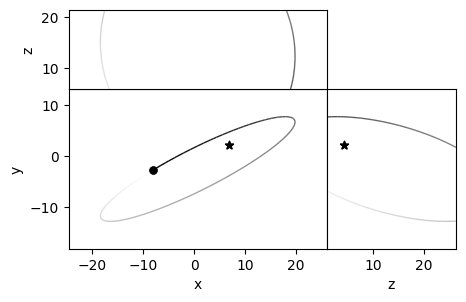

In [ ]:
op3 = rebound.OrbitPlotSet(sim_centauri)
plt.zlim()

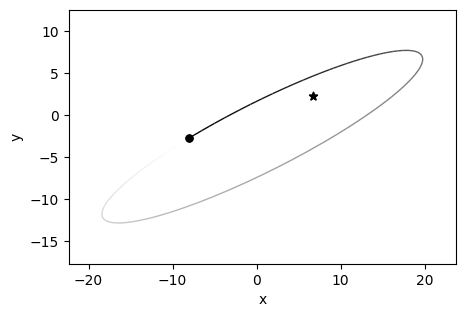

In [ ]:
# attempt at an animation
op = rebound.OrbitPlot(sim_centauri)
fig = op.fig
for i in range(3):
    sim_centauri.integrate(sim_centauri.t+0.31)
    op3.update()
    op3.fig.savefig("out_%02d.png"%i)


In [ ]:
print("MEGNO", sim_centauri.megno())
print("LCN", sim_centauri.lyapunov())
# MEGNO:
# -> infinity: chaotic
# -> 2: quasi-periodic
# https://orbi.uliege.be/bitstream/2268/290365/1/OPS2018_Poster_Pozuelos.pdf

MEGNO 1.9987547655022844
LCN 2.4296259372083376e-07


In [ ]:
print("MEGNO", sim_centauri.megno())
print("LCN", sim_centauri.lyapunov())

MEGNO 1.9987547655022844
LCN 2.4296259372083376e-07


In [5]:
# simulation
def sim_jupiter(par):
    a = par[0]
    e = par[1]
    sim = rebound.Simulation()
    sim.integrator = "whfast"
    sim.ri_whfast.safe_mode = 0
    sim.dt = 5.
    sim.add(m=1.0788, hash="cen_a")
    sim.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
            Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
    # sim.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),
    #         Omega=radians(165), omega=radians(151.0), T=278e3,
    #         hash="prox_cen")
    sim.add(m=0.001, a=a, e=e)
    sim.move_to_com()

    sim.init_megno()
    sim.exit_max_distance = 1000
    try:
        sim.integrate(1e4, exact_finish_time=0) # integrate for 10000 years, integrating to the nearest
        # timestep for each output to keep the timestep constant and preserve WHFast's symplectic nature
        megno = sim.megno()
        return megno
    except rebound.Escape:
        return 10. # At least one particle got ejected, returning large MEGNO.

In [ ]:
# test function with one set of semi-major axis and eccentricity
cen_sim((10,0.9))

10.0

In [6]:
# using code from the stability map example on the REBOUND website, the
# simulation is run with the following a and e values
# across multiple cores generating a 80 x 80 grid
with Pool() as pool:
    Ngrid = 80
    par_a = np.linspace(0.01, 100, Ngrid)
    par_e = np.linspace(0.,0.5, Ngrid)
    parameters = []
    for e in par_e:
        for a in par_a:
            parameters.append((a,e))
    results = pool.map(sim_jupiter,parameters)

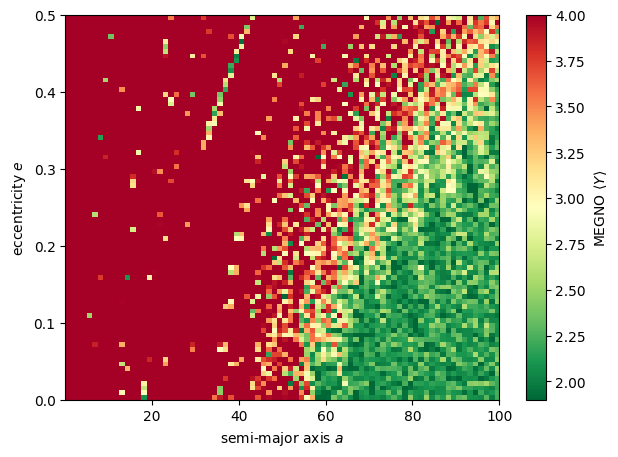

In [7]:
# plotting the results using code from REBOUND
results2d_jupiter_small = np.array(results).reshape(Ngrid,Ngrid)
%matplotlib inline
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(111)
extent = [min(par_a),max(par_a),min(par_e),max(par_e)]
ax.set_xlim(extent[0],extent[1])
ax.set_xlabel("semi-major axis $a$")
ax.set_ylim(extent[2],extent[3])
ax.set_ylabel("eccentricity $e$")
im = ax.imshow(results2d_jupiter_small, interpolation="none", vmin=1.9, vmax=4, cmap="RdYlGn_r", origin="lower", aspect='auto', extent=extent)
cb = plt.colorbar(im, ax=ax)
cb.set_label("MEGNO $\\langle Y \\rangle$")

In [17]:
# writing a function for the above method in terms of timestep, planet mass, pixel width and integration time
def stability_map(planet_mass, dt=5, pixel_width=80, time=1e4):
    # simulation
    def sim_jupiter(par):
        a = par[0]
        e = par[1]
        sim = rebound.Simulation()
        sim.integrator = "whfast"
        sim.ri_whfast.safe_mode = 0
        sim.dt = dt
        sim.add(m=1.0788, hash="cen_a")
        sim.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
                Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
        # sim.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),
        #         Omega=radians(165), omega=radians(151.0), T=278e3,
        #         hash="prox_cen")
        sim.add(m=planet_mass, a=a, e=e)
        sim.move_to_com()

        sim.init_megno()
        sim.exit_max_distance = 1000
        try:
            sim.integrate(time, exact_finish_time=0) # integrate for time years, integrating to the nearest
            # timestep for each output to keep the timestep constant and preserve WHFast's symplectic nature
            megno = sim.megno()
            return megno
        except rebound.Escape:
            return 10. # At least one particle got ejected, returning large MEGNO.

    # using code from the stability map example on the REBOUND website, the
    # simulation is run with the following a and e values
    # across multiple cores generating a 80 x 80 grid
    with Pool() as pool:
        Ngrid = pixel_width
        par_a = np.linspace(0.01, 100, Ngrid)
        par_e = np.linspace(0.,0.5, Ngrid)
        parameters = []
        for e in par_e:
            for a in par_a:
                parameters.append((a,e))
        results = pool.map(sim_jupiter,parameters)

    # plotting the results using code from REBOUND
    results2d = np.array(results).reshape(Ngrid,Ngrid)

    fig = plt.figure(figsize=(7,5))
    ax = plt.subplot(111)
    extent = [min(par_a),max(par_a),min(par_e),max(par_e)]
    ax.set_xlim(extent[0],extent[1])
    ax.set_xlabel("semi-major axis $a$")
    ax.set_ylim(extent[2],extent[3])
    ax.set_ylabel("eccentricity $e$")
    im = ax.imshow(results2d, interpolation="none", vmin=1.9, vmax=4, cmap="RdYlGn_r", origin="lower", aspect='auto', extent=extent)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("MEGNO $\\langle Y \\rangle$")

    return results2d

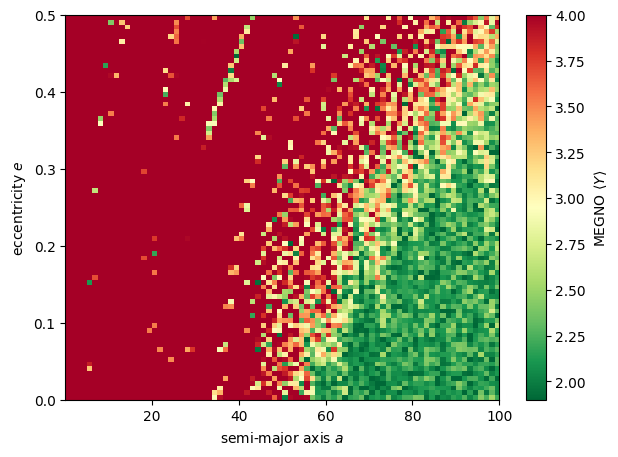

In [13]:
# testing the integrator converges by reducing the timestep by two and ensuring
# the same fraction of orbits go chaotic
lower_time_step = stability_map(0.001, dt=5/2)

In [27]:
# calculating the ratios of orbits which go unstable for each timestep. Here the threshold for instability was taken to be 4.
ratio_chaotic_1 = np.sum(results2d_jupiter_small >= 4)/(80*80)
ratio_chaotic_2 = np.sum(lower_time_step >= 4)/(80*80)
print(ratio_chaotic_1)
print(ratio_chaotic_2)

# similar ratios, hence the integrator converges (slightly higher ratio due to lower timestep)

0.57921875
0.5871875


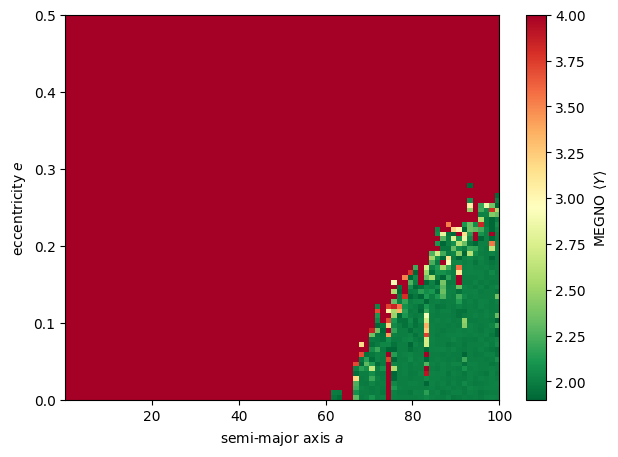

In [45]:
# increasing the integration time with resolution (80 x 80)
results_jupiter = stability_map(0.001, pixel_width=80, time=1e6)

In [46]:
# calculating the ratio of orbits which go unstable over the span of a million years
ratio_jupiter = np.sum(results_jupiter >= 4)/(80*80)
print(ratio_jupiter)

0.88265625


0.8821875


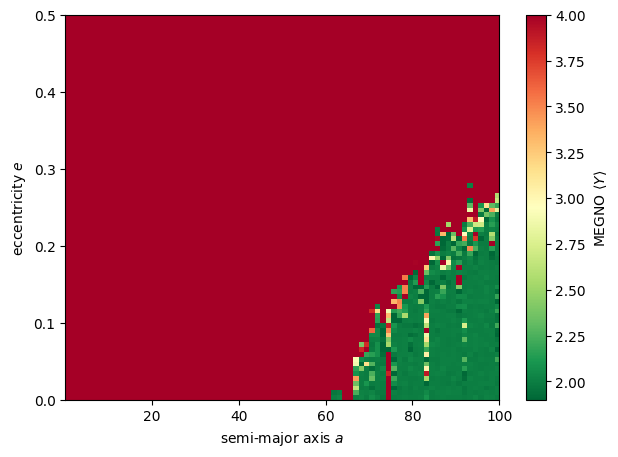

In [30]:
# increasing the the timestep by two (decreasing by two takes too long) with resolution (80 x 80)
results_2x_timestep = stability_map(0.001, pixel_width=80, dt=5*2, time=1e6)
ratio_2x_timestep = np.sum(results_2x_timestep >= 4)/(80*80)
print(ratio_2x_timestep)
# similar ratios, hence the integrator converges (slightly higher ratio due to lower timestep, but lower due to the longer integration time)

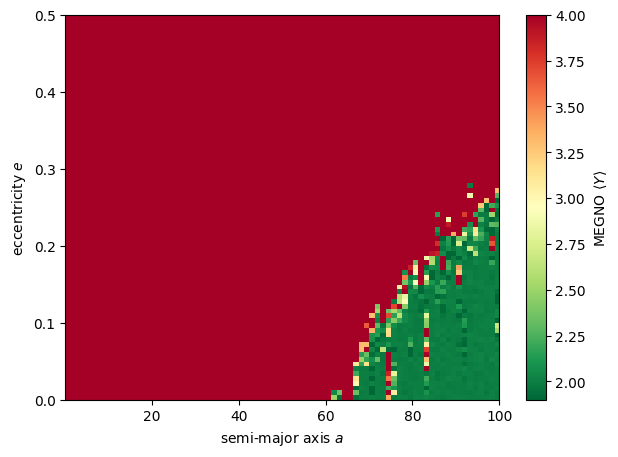

In [42]:
# plotting the stability map for an Earth-mass planet
results_earth = stability_map(0.000003, pixel_width=80, dt=5, time=1e6)

0.881875


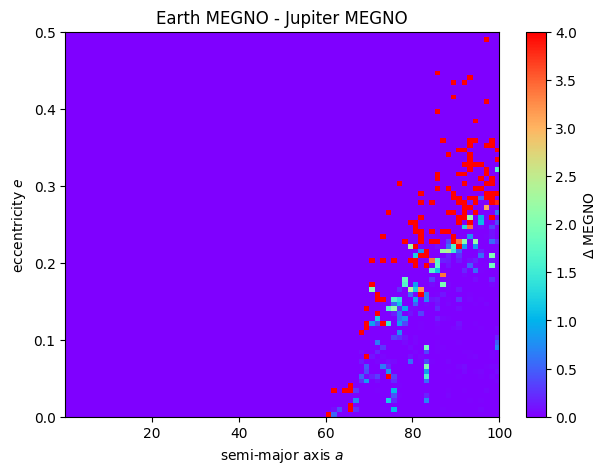

In [53]:
# calculating the corresponding Earth ratio and finding the difference between the two MEGNO arrays
ratio_earth = np.sum(results_earth >= 4)/(80*80)
print(ratio_earth)
difference = results_earth - results_jupiter

fig = plt.figure(figsize=(7,5))
ax = plt.subplot(111)
extent = [0.01, 100, 0, 0.5]
ax.set_xlim(extent[0],extent[1])
ax.set_xlabel("semi-major axis $a$")
ax.set_ylim(extent[2],extent[3])
ax.set_ylabel("eccentricity $e$")
plt.title("Earth MEGNO - Jupiter MEGNO")
im = ax.imshow(difference, interpolation="none", vmin=0, vmax=4, cmap="rainbow", origin="lower", aspect='auto', extent=extent)
cb = plt.colorbar(im, ax=ax)
cb.set_label("$\\Delta$ MEGNO")

We can see that the difference in MEGNO is zero for the most stable and unstable orbits. The biggest difference lies in the orbits in between, which are expected to have a large discrepency in MEGNO since these orbits are not entirely stable.

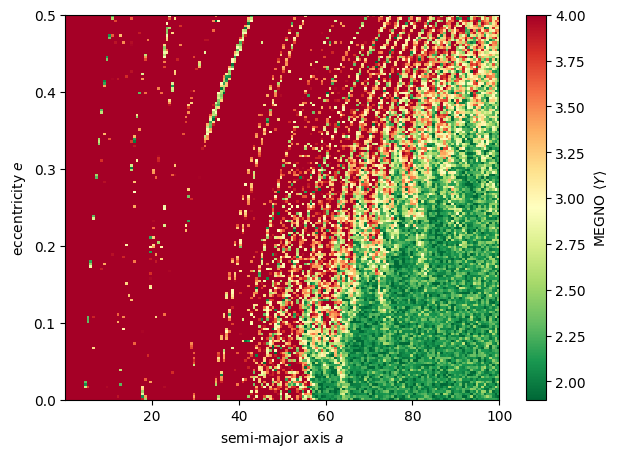

In [ ]:
# lower integration time and higher resolution Jupiter (1e4 years and 160 x 160)
higher_resolution_jupiter = stability_map(0.001, pixel_width=160, time=1e4)

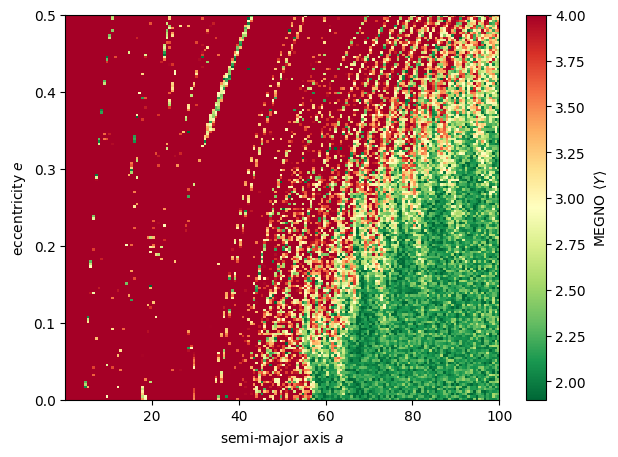

In [9]:
# lower integration time and higher resolution Earth (1e4 years and 160 x 160)
higher_resolution_earth = stability_map(0.000003, pixel_width=160, time=1e4)

We have so far looked at planets orbiting the binary system with a large semi-major axis. Now we will look at planets orbiting Alpha Centauri A. This star was chosen as it hosts a candidate giant exoplanet within its habitable zone.

In [38]:
# adding the planet to Alpha Centauri A and then adding B (planet orbiting A rather than the binary system)
def stability_map_A(planet_mass, dt=5, pixel_width=80, time=1e4, max_a=6):
    # simulation
    def sim_cen_A(par):
        a = par[0]
        e = par[1]
        sim = rebound.Simulation()
        sim.integrator = "whfast"
        sim.ri_whfast.safe_mode = 0
        sim.dt = dt
        sim.add(m=1.0788, hash="cen_a")
        sim.add(m=planet_mass, a=a, e=e)
        sim.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
                Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
        # sim.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),      # Removing Proxima Centauri
        #         Omega=radians(165), omega=radians(151.0), T=278e3,
        #         hash="prox_cen")
        sim.move_to_com()

        sim.init_megno()
        sim.exit_max_distance = 1000
        try:
            sim.integrate(time, exact_finish_time=0) # integrate for time years, integrating to the nearest
            # timestep for each output to keep the timestep constant and preserve WHFast's symplectic nature
            megno = sim.megno()
            return megno
        except rebound.Escape:
            return 10. # At least one particle got ejected, returning large MEGNO.

    # using code from the stability map example on the REBOUND website, the
    # simulation is run with the following a and e values
    # across multiple cores generating a 80 x 80 grid
    with Pool() as pool:
        Ngrid = pixel_width
        par_a = np.linspace(0.1, max_a, Ngrid)
        par_e = np.linspace(0.,0.5, Ngrid)
        parameters = []
        for e in par_e:
            for a in par_a:
                parameters.append((a,e))
        results = pool.map(sim_cen_A, parameters)

    # plotting the results using code from REBOUND
    results2d = np.array(results).reshape(Ngrid,Ngrid)

    fig = plt.figure(figsize=(7,5))
    ax = plt.subplot(111)
    extent = [min(par_a),max(par_a),min(par_e),max(par_e)]
    ax.set_xlim(extent[0],extent[1])
    ax.set_xlabel("semi-major axis $a$")
    ax.set_ylim(extent[2],extent[3])
    ax.set_ylabel("eccentricity $e$")
    im = ax.imshow(results2d, interpolation="none", vmin=1.9, vmax=4, cmap="RdYlGn_r", origin="lower", aspect='auto', extent=extent)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label("MEGNO $\\langle Y \\rangle$")

    return results2d

/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


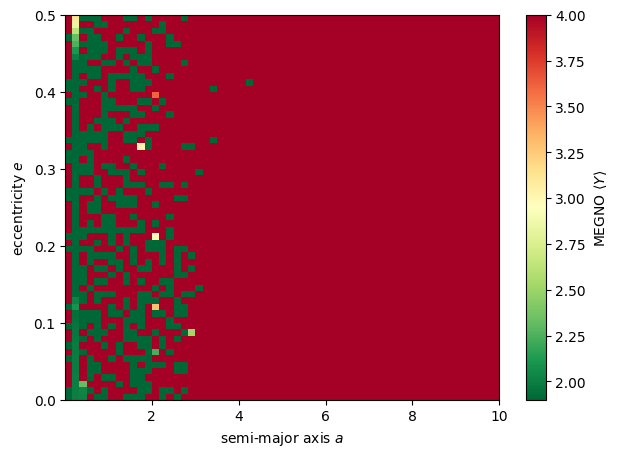

In [37]:
# making the stability map for the new simulation with duration 1e5 yrs
A_Jupiter_mass = stability_map_A(0.001, pixel_width=60, dt=1, time=1e5)

/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


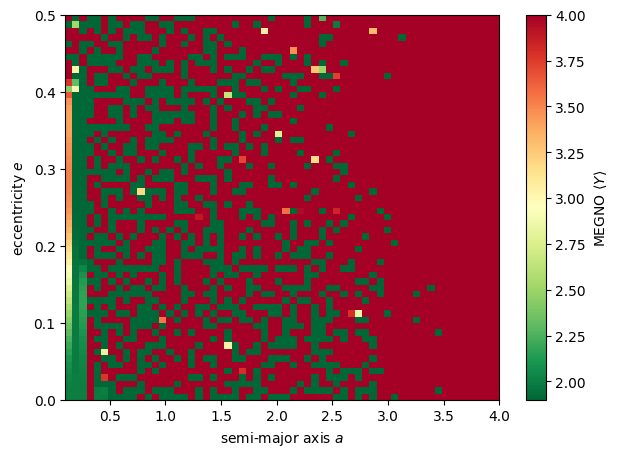

In [39]:
A_Jupiter_mass = stability_map_A(0.001, pixel_width=60, dt=0.5, time=1e5, max_a=4)
# decreasing the time step and semi-major axis due to the smaller orbits
# orbits with very small semi-major axis (0-0.1 AU) are not reliable since the
# integration time is larger than the orbital period

From above we can see that the majority of Jupiter mass stable orbits around Alpha Centauri A have semi-major axes less than 3 au. This is in agreement with Beichman, C. et al. (2025). https://iopscience.iop.org/article/10.3847/2041-8213/adf53f#apjladf53fs3.

In [83]:
# defining a function which gives us orbital information for a given a and e
def orbits(par):
    a = par[0]
    e = par[1]
    sim = rebound.Simulation()
    sim.integrator = "whfast"
    sim.ri_whfast.safe_mode = 0
    sim.dt = 0.5
    sim.add(m=1.0788, hash="cen_a")
    sim.add(m=0.001, a=a, e=e)
    sim.add(m=0.9092, a=23.3, e=0.51947, inc=radians(79.2430),
            Omega=radians(205.073), omega=radians(231.519), T=1955.564, hash="cen_b")
    # sim.add(m=0.122, a=8.2e3, e=0.497, inc=radians(124.9),      # Removing Proxima Centauri
    #         Omega=radians(165), omega=radians(151.0), T=278e3,
    #         hash="prox_cen")
    sim.move_to_com()

    sim.integrate(1e2, exact_finish_time=0)

    orbit = sim.particles[1].orbit(primary=sim.particles[0])
    return orbit

In [96]:
# a = 0.1 gives an orbital period lower than the time step
orbit1 = orbits((0.1, 0.4))
print(orbit1.P)

# a = 0.2 is the minimum semi-major axis for which we can get reliable results
# since now the orbital period is larger than the time step
orbit2 = orbits((0.2, 0))
print(orbit2.P)

0.1912104398374727
0.540833302921717


/usr/local/lib/python3.12/dist-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


For a planet orbiting a single star we have the following equation for the planets temperature.

$T_p = T_\star (1 - a)^{1/4}\sqrt(\frac{R_\star}{2D})$

This gives the following proportionality since the other factors remain constant

$T_p = k D^{-1/2}$

We can deduce that the contribution by Alpha Centauri B is negligible as follows


In [ ]:
# graphing temperature relative to the average:

distance = orbits((0.2, 0.01)).d

distance_average = orbit